\setcounter{secnumdepth}{0}

# Assignment 4 - Stochastic Processes

Name: Sam Schilder
Student #: s1154839

In [5]:
import random

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr

import scipy.signal.windows as ssw

# Exercise 1: Wiener process (2 points)

Generate samples from a Wiener process and visualise the evolution of the density (confidence interval) over time. See slide 38 of the stochastic processes lecture for an example.

## Solution 1

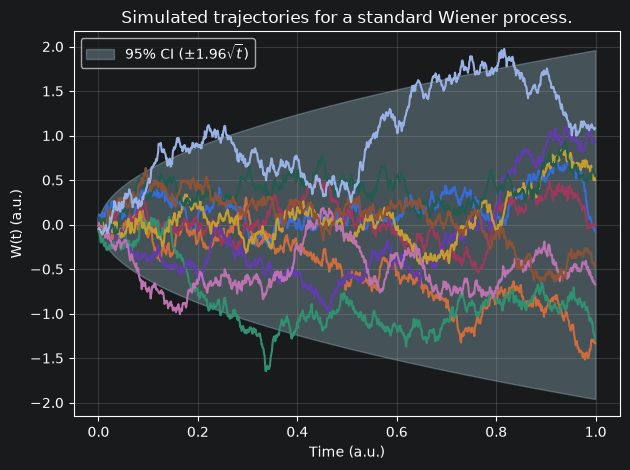

In [9]:
# define Wiener process
def Wiener_process(state, epsilon, dt):
    state = state + jnp.sqrt(dt)*epsilon  # state = previous state + stochastic process
    return state, state

# time paremeters
t0, tn, dt = 0, 1, 0.001
t = jnp.arange(t0, tn, dt)
N = len(t)
n_sims = 10  # number of simulations
x0s = jnp.zeros(n_sims)  # starting states for number of simulations

key = jax.random.PRNGKey(0)  # generate random key
epsilons = jr.normal(key, shape=(n_sims, N))  # generate stochastic process for shape n_sims X N

# simulate
f_wiener = lambda state, eps_t: Wiener_process(state, eps_t, dt)

@jax.jit
def run_simulation(inits, epsilon_matrix):
    scan = lambda init, epsilon_seq: jax.lax.scan(f_wiener, init, epsilon_seq)[1]
    return jax.vmap(scan)(inits, epsilon_matrix)

trajectories = run_simulation(x0s, epsilons)
# plot
for i in range(n_sims):
    plt.plot(t, trajectories[i, :])  # plot simulated trajectories

ci = 1.96 * jnp.sqrt(t)
plt.fill_between(t, -ci, ci, color='lightblue', alpha=0.3, label=r'95% CI ($\pm 1.96 \sqrt{t}$)')
plt.title('Simulated trajectories for a standard Wiener process.')
plt.ylabel('W(t) (a.u.)')
plt.xlabel('Time (a.u.)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Exercise 2: Compound Poisson process (3 points)

Simulate the compound Poisson process under different intensities. Compare the processes using a Gaussian and Exponential jump size distribution and describe the processes you find.

## Solution 2

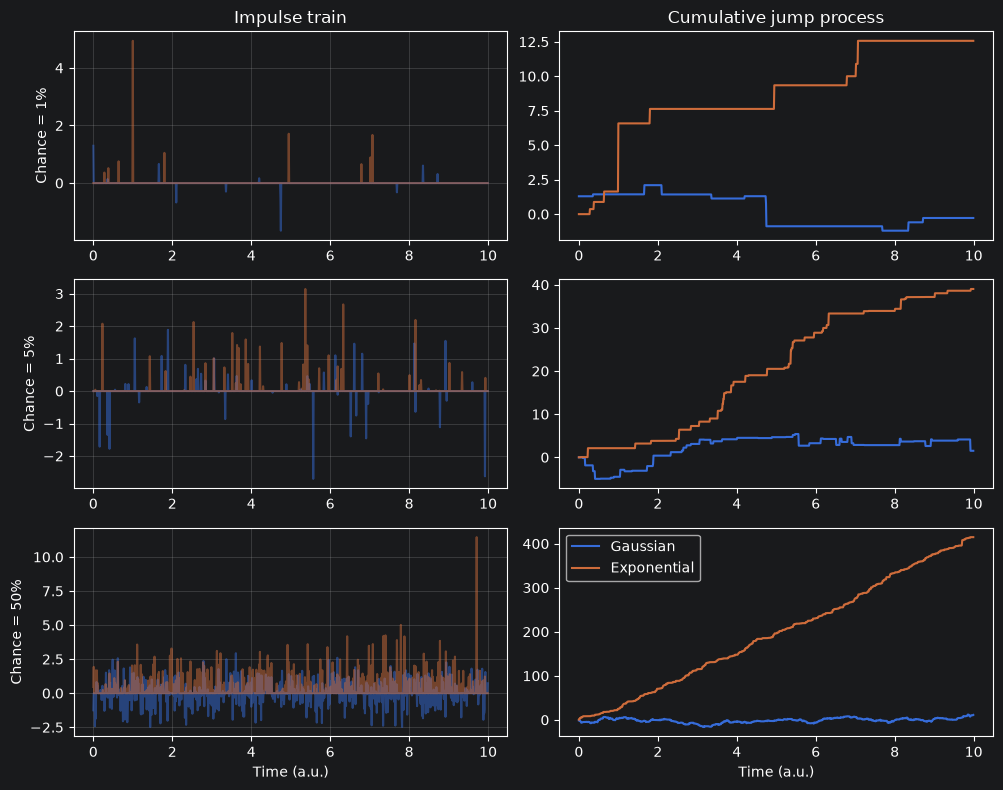

In [38]:
chances = [0.01, 0.05, 0.50]  # chance of jump happening

# define time parameters
t0 = 0
tN = 10
dt = 0.01
t = jnp.arange(t0, tN, dt)
N = len(t)  # number of samples

# plot
fig, ax = plt.subplots(len(chances), 2, figsize=(10, 8))
key = jax.random.PRNGKey(0)

for i, chance in enumerate(chances):
    # define random process
    key, subkey1, subkey2, subkey3 = jax.random.split(key, 4)

    tK_chance_gaussian = jax.random.uniform(subkey1, shape=(N,))  # generate N distributed numbers
    tK_gaussian = jnp.where(tK_chance_gaussian <= chance, 1, 0)  # sequence with 5% chance of 1 & 95% chance of 0
    shot_noise = jax.random.normal(subkey2, shape=(N,))
    shots_gaussian = tK_gaussian * shot_noise

    tk_chance_exponential = jax.random.exponential(key, shape=(N,)) # generate N exponentially distributed numbers
    tK_exponential = jnp.where(tk_chance_exponential <= chance, 1, 0)
    shots_exponential = tK_exponential * jax.random.exponential(subkey3, shape=(N,))

    # simulate cumulative jump process
    trajectories_gaussian = jnp.cumsum(shots_gaussian)
    trajectories_exponential = jnp.cumsum(shots_exponential)

    ax[i, 0].plot(t, shots_gaussian, label="Gaussian", alpha=0.5)  # impulse train
    ax[i, 0].plot(t, shots_exponential, label="Exponential", alpha=0.5)
    ax[i, 0].set_ylabel(f'Chance = {chance*100:.0f}%')
    ax[i, 0].grid(True, alpha=0.3)

    ax[i, 1].plot(t, trajectories_gaussian, label="Gaussian")  # simulate cumulative jump process
    ax[i, 1].plot(t, trajectories_exponential, label="Exponential")

ax[0,0].set_title('Impulse train')
ax[0,1].set_title('Cumulative jump process')
ax[-1,0].set_xlabel('Time (a.u.)')
ax[-1,1].set_xlabel('Time (a.u.)')

plt.legend()
plt.tight_layout()
plt.show()

# Exercise 3: Jump-diffusion process (5 points)

Simulate a stochastic harmonic oscillator, where the velocity is subjected to both a **Wiener process** and **jump processes**. Use a Gaussian jump distribution in the jump process. Choose the parameters such that the noise is visible but does not completely dominate the dynamics.

Generate an ensemble of trajectories. Plot a couple of trajectories of this ensemble and plot the confidence interval of the whole ensemble. Explain what happens with the confidence interval when you increase the number of samples in your ensemble.

## Solution 3

In [50]:
def stochastic_harmonic_oscillator(X, k, sigma_w, W, sigma_s, shot):
    """
    Simple harmonic oscillator model
    X: state vector [x, xdot]
    k: omega
    """
    x, xdot = X
    xdot = -k*x + sigma_w*W + sigma_s*shot
    return jnp.array([xdot, -k*x])

# define parmaters
t0 = 0  # time
tN = 10
dt = 0.01
t = jnp.arange(t0, tN, dt)
N = len(t)

X = 1, 0  # starting state

# set up stochastic processes
key = jax.random.PRNGKey(0)  # generate random keys
key, subkey1, subkey2, subkey3 = jax.random.split(key, 4)

epsilon = jr.normal(key, shape=(N))  # set up Wiener process

tK_chance = jax.random.uniform(subkey1, shape=(N,))  # set up jump process
tK = jnp.where(tK_chance_gaussian <= chance, 1, 0)
shot_size = jax.random.normal(subkey2, shape=(N,))
shots = tK * shot_size


# simulation
f = lambda state, dt: stochastic_harmonic_oscillator(state, dt, k=1.0, gamma=1.0)


@jax.jit
def run_simulation(inits, epsilon, shots):
    scan = lambda init, epsilon, shot: jax.lax.scan(f, init, epsilon, shots)[1]
    return jax.vmap(scan)(inits, epsilon, shots)

trajectories = run_simulation(X, epsilon, shots)


ValueError: vmap was requested to map its argument along axis 0, which implies that its rank should be at least 1, but is only 0 (its shape is ())

The confidence interval becomes wider when the number of trajectories increases, but converges to +- 0.5.